<a href="https://colab.research.google.com/github/pil-hue/ML_Project_and_Labs/blob/main/AIML_Module_01_Lab_01_Features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extracting features from data

Module 1, Lab 1<br>



In [72]:
! pip install wikipedia

import wikipedia
import nltk
from nltk.util import ngrams
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import re
import unicodedata
import plotly.express as px
import pandas as pd

# Part 1: Features of text
How do we apply machine learning on text? We can't directly use the text as input to our algorithms. We need to convert them to features. In this notebook, we will explore a simple way of converting text to features.

Let us download a few documents off Wikipedia.

In [73]:
topic1 = 'Giraffe'
topic2 = 'Elephant'

wikipedia.set_lang('en')

eng1 = wikipedia.page(topic1).content
eng2 = wikipedia.page(topic2).content

wikipedia.set_lang('fr')

fr1 = wikipedia.page('Girafe').content
fr2 = wikipedia.page('Éléphant').content

This is what the text looks like:

In [74]:
fr2

'Les éléphants sont des mammifères proboscidiens de la famille des Éléphantidés. \nIls correspondent aujourd\'hui à trois espèces réparties en deux genres distincts. L\'éléphant de savane d\'Afrique et l\'éléphant de forêt d\'Afrique, autrefois regroupés sous la même espèce d\'« éléphant d\'Afrique », appartiennent au genre Loxodonta, tandis que l\'éléphant d\'Asie, anciennement appelé « éléphant indien », appartient au genre Elephas. Ils se différencient par certaines caractéristiques anatomiques, les éléphants d\'Asie étant en général plus petits avec des oreilles plus petites, ou encore une différence du bout de la trompe. Ces espèces survivantes font localement l\'objet de programmes ou de projets de réintroduction et de protection.\nLe mot français « éléphant » vient du mot latin elephantus qui tire son origine du grec ἐλέφας / eléphas, « ivoire » ou « éléphant ».\nL\'éléphant apparaît dans de nombreuses cultures. Il est symbole de sagesse en Asie et est  connu pour sa mémoire et 

We need to clean this up a bit. Let us remove all the special characters and keep only 26 letters and space. Note that this will remove accented characters in French also. We are also removing all the numbers and spaces. So this is not an ideal solution.

In [75]:
def cleanup(text):
  text = text.lower()  # make it lowercase
  text = re.sub('[^a-z]+', '', text) # only keep characters
  return text

In [76]:
eng1 = cleanup(eng1)
eng2 = cleanup(eng2)
fr1 = cleanup(fr1)
fr2 = cleanup(fr2)

In [77]:
print(eng1)

...


Now let us calculate the frequency of the character n-grams. N-grams are groups of characters of size n. A unigram is a single character and a bigram is a group of two characters and so on.

Let us count the frequency of each character in a text and plot it in a histogram.

In [78]:
# convert a tuple of characters to a string
def tuple2string(tup):
  st = ''
  for ii in tup:
    st = st + ii
  return st

# convert a tuple of tuples to a list of strings
def key2string(keys):
  return [tuple2string(i) for i in keys]

# plot the histogram
def plothistogram(ngram):
  keys = key2string(ngram.keys())
  values = list(ngram.values())

  # sort the keys in alphabetic order
  combined = zip(keys, values)
  zipped_sorted = sorted(combined, key=lambda x: x[0])
  keys, values = map(list, zip(*zipped_sorted))
  plt.bar(keys, values)

Let us compare the histograms of English pages and French pages. Can you spot a difference?

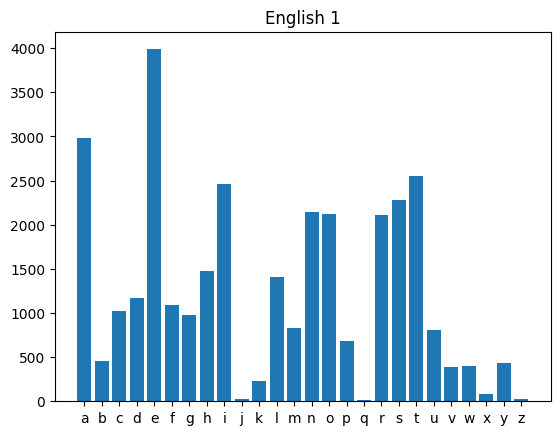

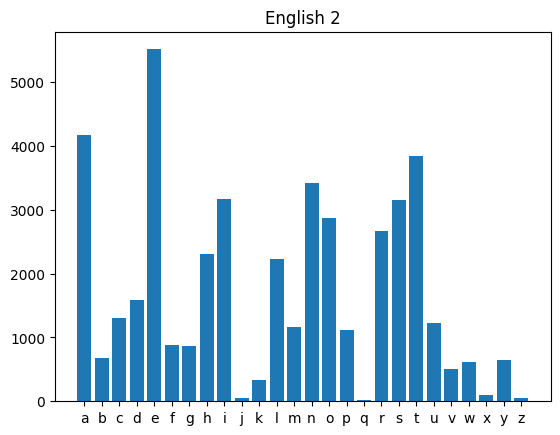

In [79]:
unigram_eng1 = Counter(ngrams(eng1,1))
plothistogram(unigram_eng1)
plt.title('English 1')
plt.show()
unigram_eng2 = Counter(ngrams(eng2,1))
plothistogram(unigram_eng2)
plt.title('English 2')
plt.show()

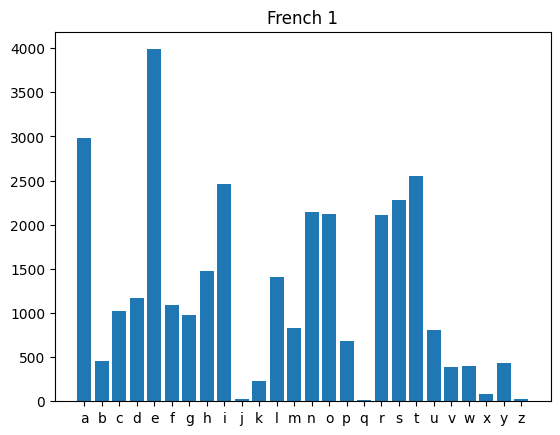

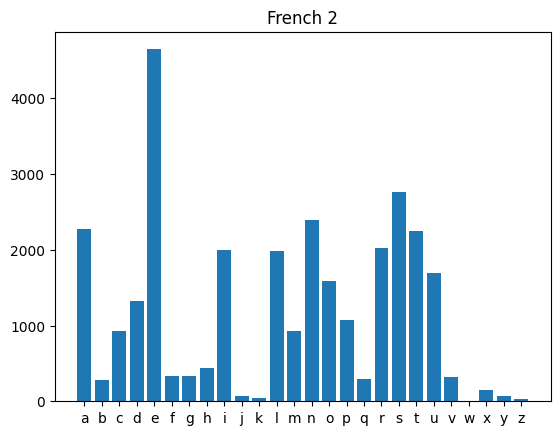

In [80]:
unigram_fr1 = Counter(ngrams(fr1,1))
plothistogram(unigram_eng1)
plt.title('French 1')
plt.show()
unigram_fr2 = Counter(ngrams(fr2,1))
plothistogram(unigram_fr2)
plt.title('French 2')
plt.show()

We can see that the unigrams for French and English are very similar. So this is not a good feature if we want to distinguish between English and French. Let us look at bigrams.

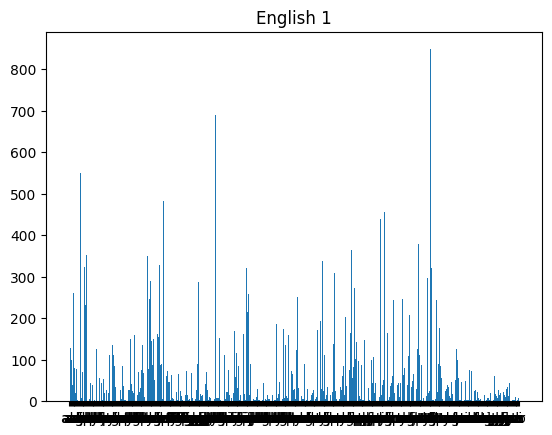

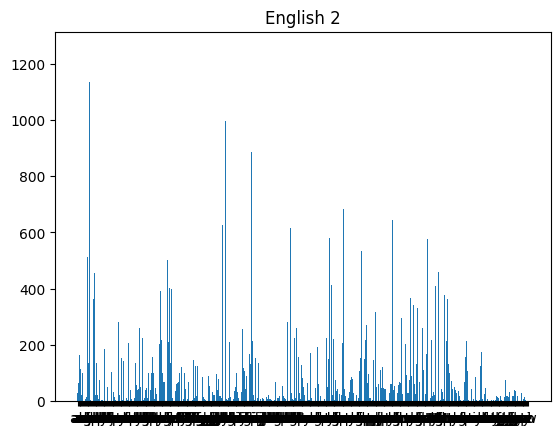

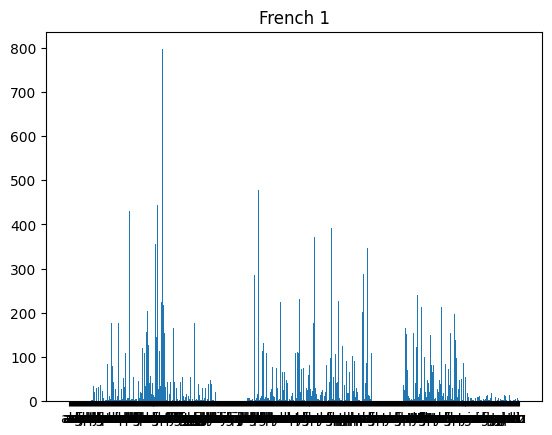

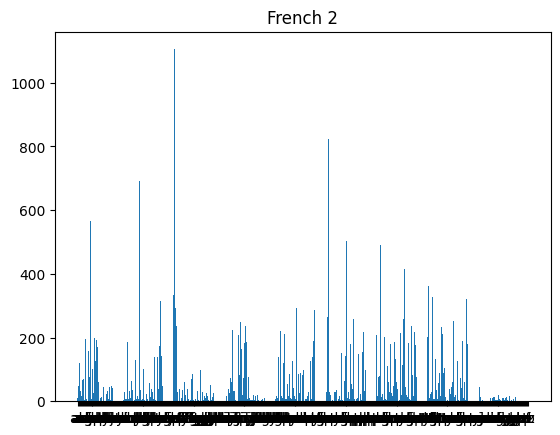

In [81]:
bigram_eng1 = Counter(ngrams(eng1,2)) # bigrams
plothistogram(bigram_eng1)
plt.title('English 1')
plt.show()

bigram_eng2 = Counter(ngrams(eng2,2))
plothistogram(bigram_eng2)
plt.title('English 2')
plt.show()

bigram_fr1 = Counter(ngrams(fr1,2))
plothistogram(bigram_fr1)
plt.title('French 1')
plt.show()

bigram_fr2 = Counter(ngrams(fr2,2))
plothistogram(bigram_fr2)
plt.title('French 2')
plt.show()

Another way to visualize bigrams is to use a 2-dimensional graph.

In [82]:
def plotbihistogram(ngram):
  freq = np.zeros((26,26))
  for ii in range(26):
    for jj in range(26):
      freq[ii,jj] = ngram[(chr(ord('a')+ii), chr(ord('a')+jj))]
  plt.imshow(freq, cmap = 'jet')
  return freq

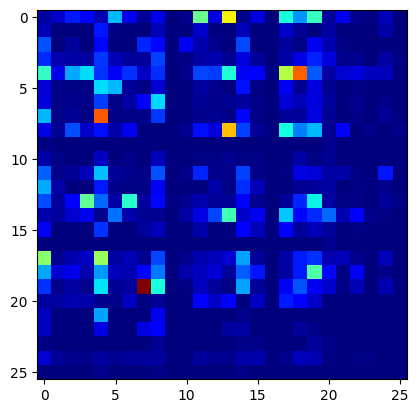

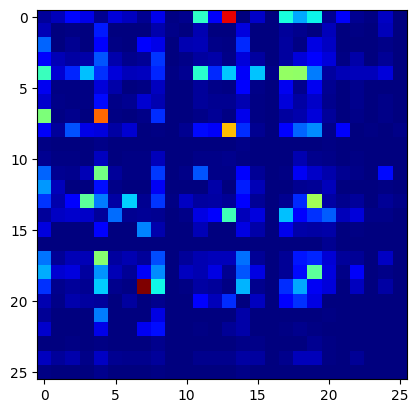

In [83]:
bieng1 = plotbihistogram(bigram_eng1)
plt.show()
bieng2 = plotbihistogram(bigram_eng2)

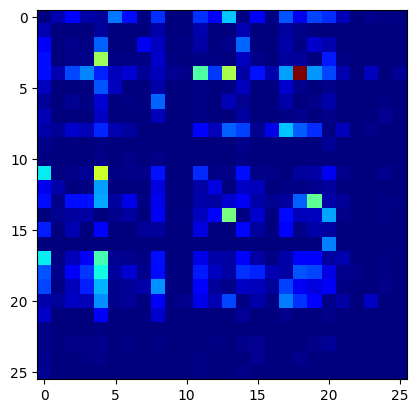

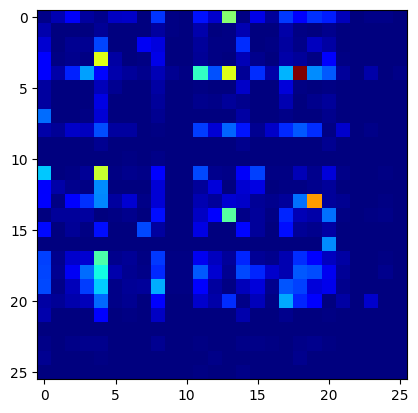

In [84]:
bifr1 = plotbihistogram(bigram_fr1)
plt.show()
bifr2 = plotbihistogram(bigram_fr2)

Let us look at the top 10 ngrams for each text.

In [85]:
from IPython.core.debugger import set_trace

def ind2tup(ind):
  ind = int(ind)
  i = int(ind/26)
  j = int(ind%26)
  return (chr(ord('a')+i), chr(ord('a')+j))

def ShowTopN(bifreq, n=10):
  f = bifreq.flatten()
  arg = np.argsort(-f)
  for ii in range(n):
    print(f'{ind2tup(arg[ii])} : {f[arg[ii]]}')

In [86]:
print('\nEnglish 1:')
ShowTopN(bieng1)
print('\nEnglish 2:')
ShowTopN(bieng2)
print('\nFrench 1:')
ShowTopN(bifr1)
print('\nFrench 2:')
ShowTopN(bifr2)


English 1:
('t', 'h') : 848.0
('h', 'e') : 690.0
('e', 's') : 683.0
('i', 'n') : 598.0
('a', 'n') : 550.0
('e', 'r') : 482.0
('r', 'e') : 455.0
('r', 'a') : 438.0
('a', 'l') : 407.0
('n', 'd') : 397.0

English 2:
('t', 'h') : 1251.0
('a', 'n') : 1134.0
('h', 'e') : 997.0
('i', 'n') : 885.0
('n', 't') : 682.0
('e', 'r') : 662.0
('e', 's') : 656.0
('r', 'e') : 644.0
('h', 'a') : 628.0
('l', 'e') : 615.0

French 1:
('e', 's') : 796.0
('l', 'e') : 478.0
('e', 'n') : 444.0
('d', 'e') : 430.0
('o', 'n') : 392.0
('n', 't') : 372.0
('e', 'l') : 355.0
('r', 'e') : 346.0
('s', 'e') : 298.0
('r', 'a') : 287.0

French 2:
('e', 's') : 1105.0
('n', 't') : 823.0
('d', 'e') : 690.0
('e', 'n') : 686.0
('l', 'e') : 652.0
('a', 'n') : 566.0
('o', 'n') : 504.0
('r', 'e') : 492.0
('e', 'l') : 456.0
('s', 'e') : 414.0


###1. Try with different languages

Here the languages used are Spanish and Italian.

In [87]:
wikipedia.set_lang('es')

es1 = wikipedia.page('Jirafa').content
es2 = wikipedia.page('Elefante').content

wikipedia.set_lang('it')

it1 = wikipedia.page('Giraffa').content
it2 = wikipedia.page('Elefante').content

We now clean up the text.

In [88]:
es1 = cleanup(es1)
es2 = cleanup(es2)
it1 = cleanup(it1)
it2 = cleanup(it2)

This is an example of the cleaned up text.

In [89]:
print(es1)

...


We find out the unigrams of both the languages.

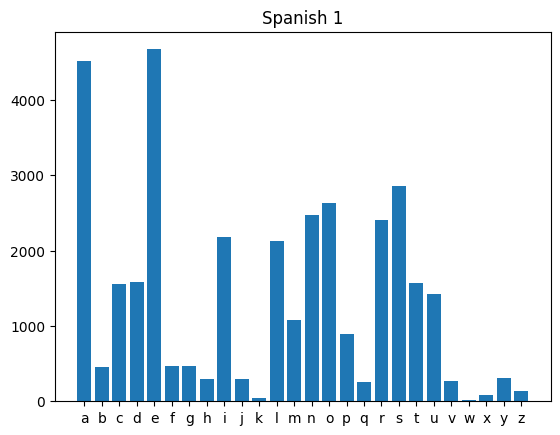

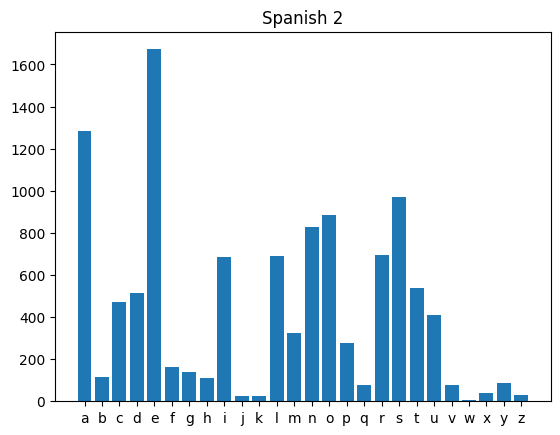

In [90]:
unigram_es1 = Counter(ngrams(es1,1))
plothistogram(unigram_es1)
plt.title('Spanish 1')
plt.show()
unigram_es2 = Counter(ngrams(es2,1))
plothistogram(unigram_es2)
plt.title('Spanish 2')
plt.show()

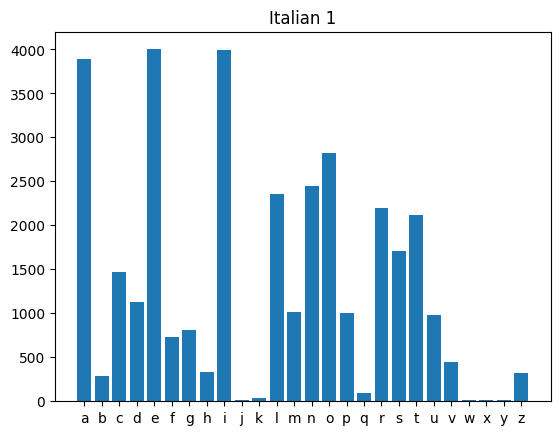

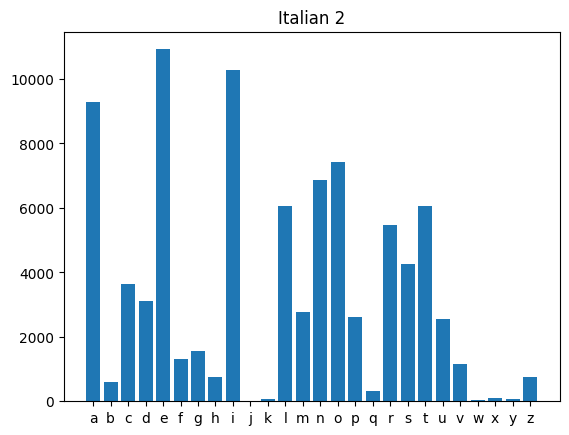

In [91]:
unigram_it1 = Counter(ngrams(it1,1))
plothistogram(unigram_it1)
plt.title('Italian 1')
plt.show()
unigram_it2 = Counter(ngrams(it2,1))
plothistogram(unigram_it2)
plt.title('Italian 2')
plt.show()

Now, we find out the bigrams.

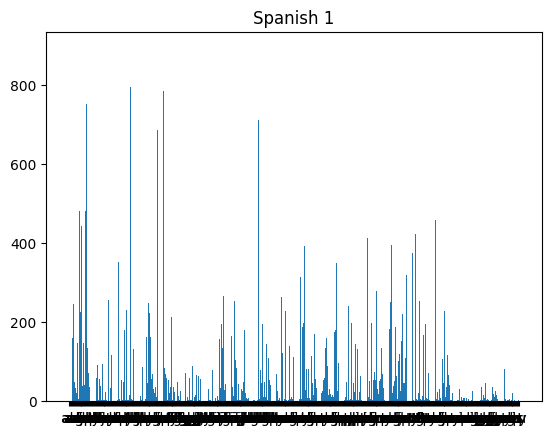

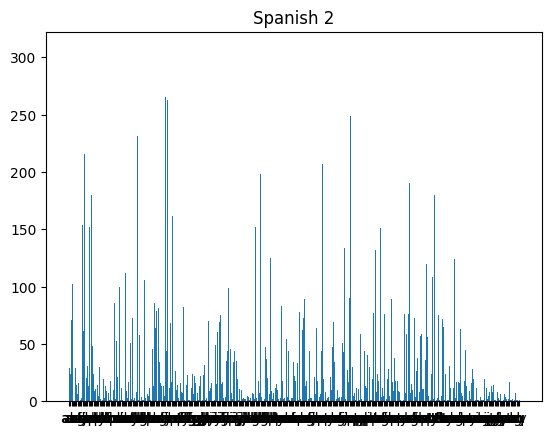

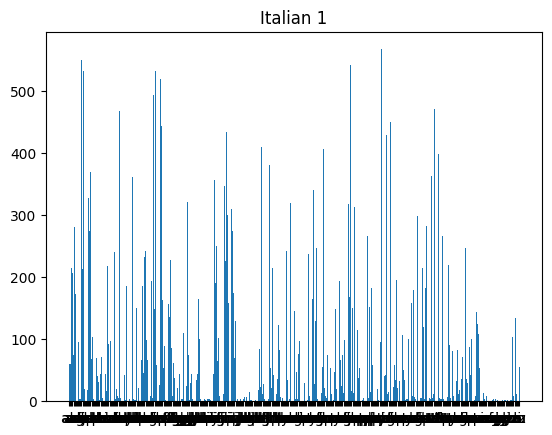

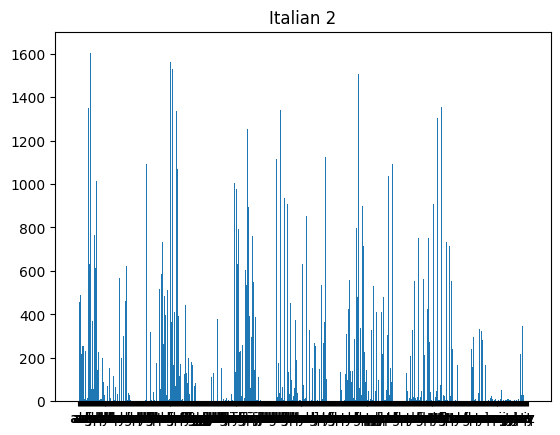

In [92]:
bigram_es1 = Counter(ngrams(es1,2))
plothistogram(bigram_es1)
plt.title('Spanish 1')
plt.show()

bigram_es2 = Counter(ngrams(es2,2))
plothistogram(bigram_es2)
plt.title('Spanish 2')
plt.show()

bigram_it1 = Counter(ngrams(it1,2))
plothistogram(bigram_it1)
plt.title('Italian 1')
plt.show()

bigram_it2 = Counter(ngrams(it2,2))
plothistogram(bigram_it2)
plt.title('Italian 2')
plt.show()

Plotting the bi histogram, we get:

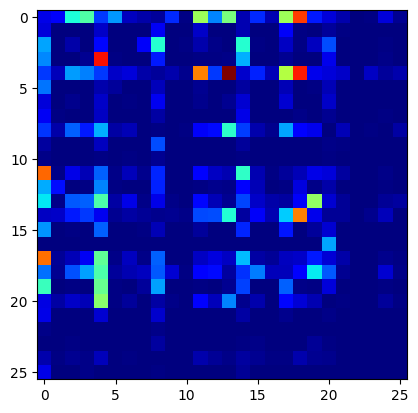

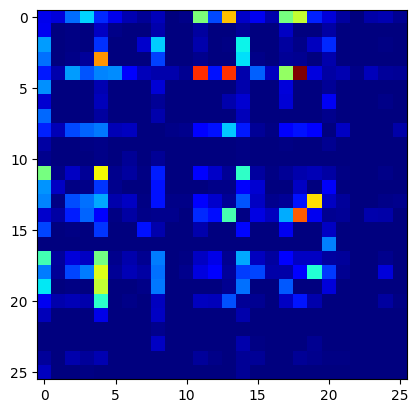

In [93]:
bies1 = plotbihistogram(bigram_es1)
plt.show()
bies2 = plotbihistogram(bigram_es2)

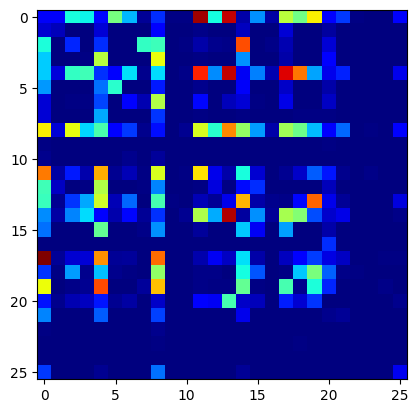

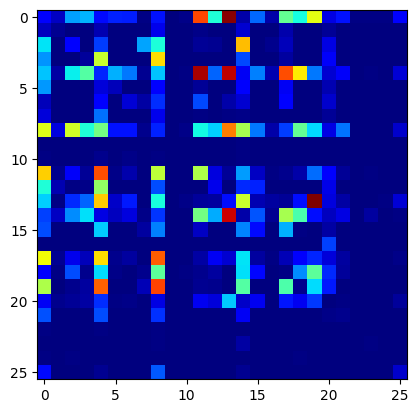

In [94]:
biit1 = plotbihistogram(bigram_it1)
plt.show()
biit2 = plotbihistogram(bigram_it2)

Now, we find out top ten bigrams for both languages.

In [95]:
print('\nSpanish 1:')
ShowTopN(bies1)
print('\nSpanish 2:')
ShowTopN(bies2)
print('\nItalian 1:')
ShowTopN(biit1)
print('\nItalian 2:')
ShowTopN(biit2)


Spanish 1:
('e', 'n') : 890.0
('d', 'e') : 794.0
('e', 's') : 785.0
('a', 's') : 752.0
('l', 'a') : 711.0
('r', 'a') : 703.0
('o', 's') : 688.0
('e', 'l') : 687.0
('e', 'r') : 507.0
('a', 'r') : 482.0

Spanish 2:
('e', 's') : 307.0
('e', 'l') : 265.0
('e', 'n') : 263.0
('o', 's') : 249.0
('d', 'e') : 231.0
('a', 'n') : 216.0
('n', 't') : 207.0
('l', 'e') : 198.0
('s', 'e') : 190.0
('t', 'e') : 180.0

Italian 1:
('r', 'a') : 567.0
('a', 'l') : 550.0
('o', 'n') : 541.0
('e', 'n') : 532.0
('a', 'n') : 532.0
('e', 'r') : 519.0
('e', 'l') : 494.0
('t', 'e') : 470.0
('c', 'o') : 468.0
('n', 't') : 455.0

Italian 2:
('n', 't') : 1620.0
('a', 'n') : 1605.0
('e', 'l') : 1561.0
('e', 'n') : 1530.0
('o', 'n') : 1507.0
('t', 'i') : 1356.0
('a', 'l') : 1349.0
('l', 'e') : 1340.0
('e', 'r') : 1337.0
('r', 'i') : 1311.0


###2. The topics we used are quite similar, wikipedia articles of 'elephant' and 'giraffe'. What happens if we use very different topics? What if we use text from another source than Wikipedia?

Here, we take two very different topics: Mountain, and Chocolate

In [96]:
wikipedia.set_lang('en')

eng3 = wikipedia.page('Mountain').content
eng4 = wikipedia.page('Chocolate').content

wikipedia.set_lang('fr')

fr3 = wikipedia.page('Montagne').content
fr4 = wikipedia.page('Chocolat').content

In [97]:
eng3 = cleanup(eng3)
eng4 = cleanup(eng4)
fr3 = cleanup(fr3)
fr4 = cleanup(fr4)

In [98]:
print(fr3)

...


Plotting the unigrams, we get:

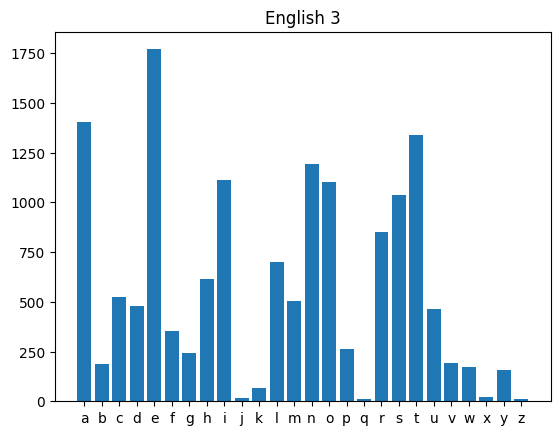

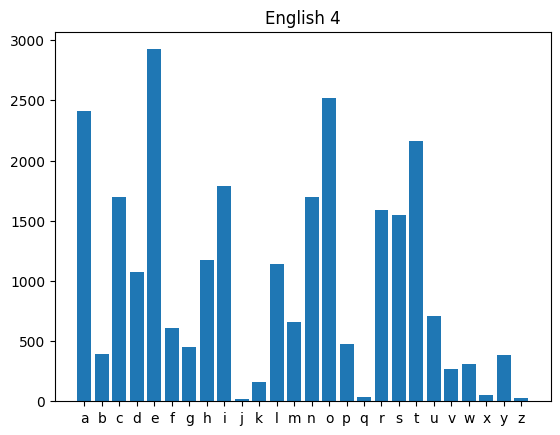

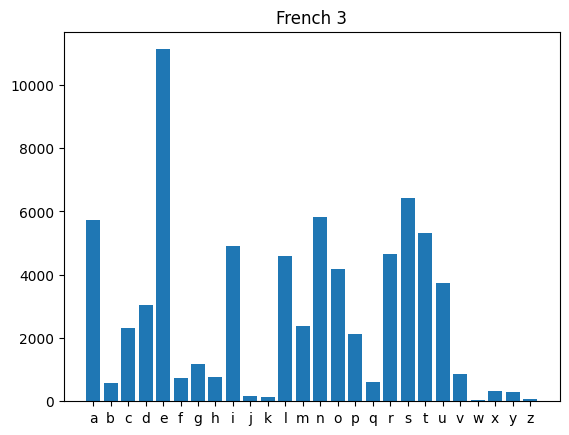

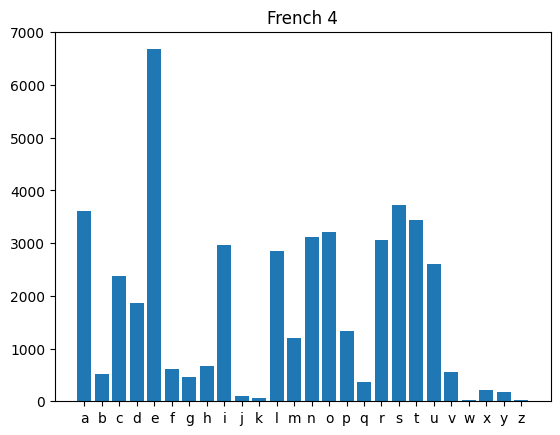

In [99]:
unigram_eng3 = Counter(ngrams(eng3,1))
plothistogram(unigram_eng3)
plt.title('English 3')
plt.show()
unigram_eng4 = Counter(ngrams(eng4,1))
plothistogram(unigram_eng4)
plt.title('English 4')
plt.show()

unigram_fr3 = Counter(ngrams(fr3,1))
plothistogram(unigram_fr3)
plt.title('French 3')
plt.show()
unigram_fr4 = Counter(ngrams(fr4,1))
plothistogram(unigram_fr4)
plt.title('French 4')
plt.show()

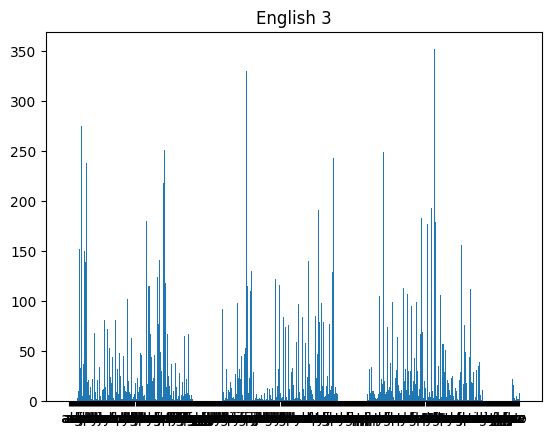

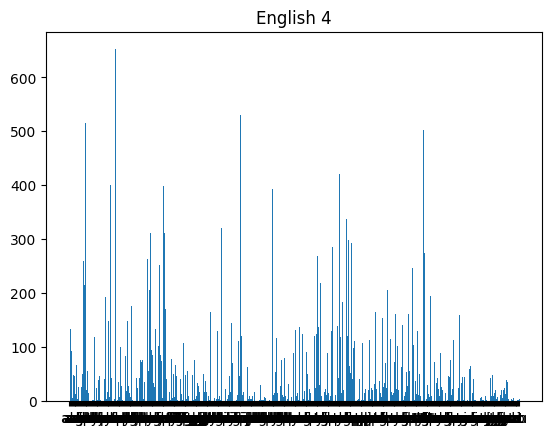

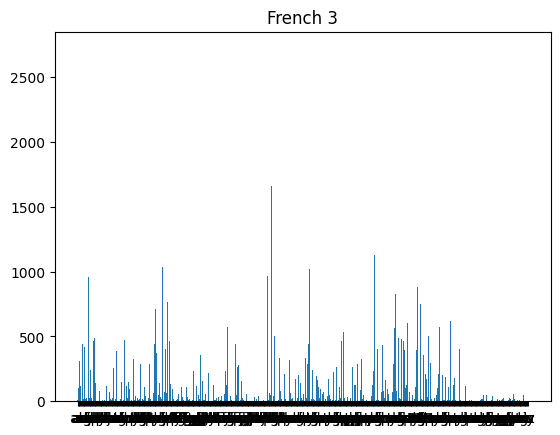

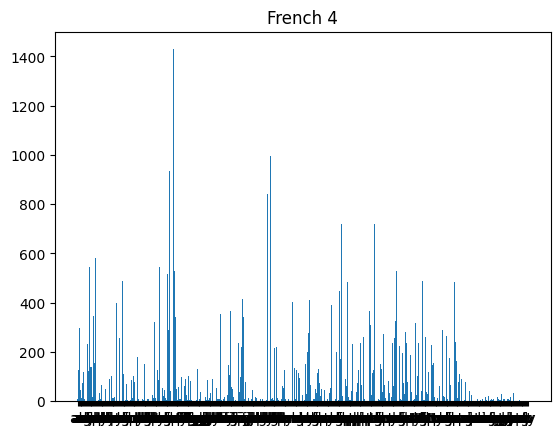

In [100]:
bigram_eng3 = Counter(ngrams(eng3,2))
plothistogram(bigram_eng3)
plt.title('English 3')
plt.show()

bigram_eng4 = Counter(ngrams(eng4,2))
plothistogram(bigram_eng4)
plt.title('English 4')
plt.show()

bigram_fr3 = Counter(ngrams(fr3,2))
plothistogram(bigram_fr3)
plt.title('French 3')
plt.show()

bigram_fr4 = Counter(ngrams(fr4,2))
plothistogram(bigram_fr4)
plt.title('French 4')
plt.show()

Plotting the bigrams, we get:

Histograms of English 3 and English 4

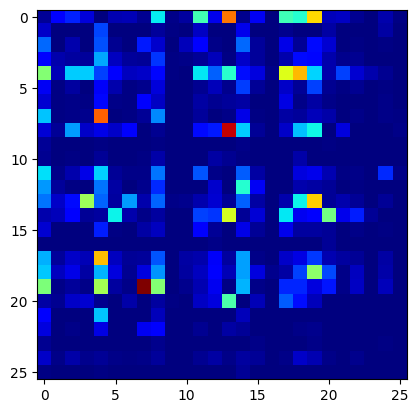

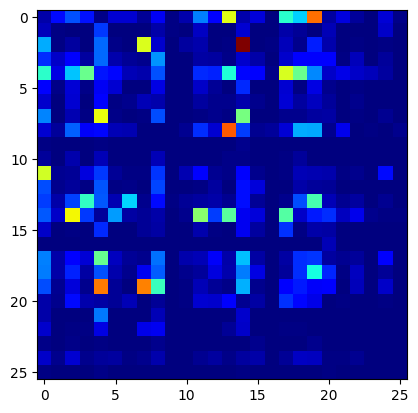

In [101]:
bieng3 = plotbihistogram(bigram_eng3)
plt.show()
bieng4 = plotbihistogram(bigram_eng4)

Histograms of French 3 and French 4

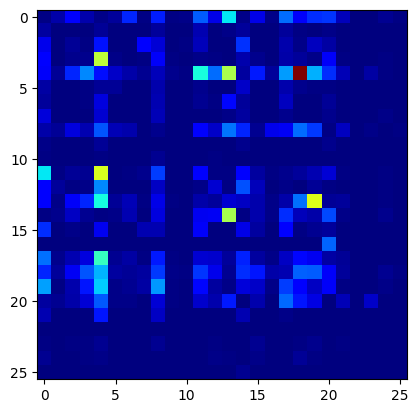

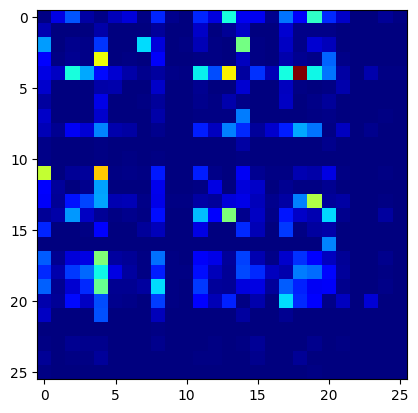

In [102]:
bifr3 = plotbihistogram(bigram_fr3)
plt.show()
bifr4 = plotbihistogram(bigram_fr4)

Now, we find out top ten bigrams for each:

In [103]:
print('\nEnglish 3:')
ShowTopN(bieng3)
print('\nEnglish 4:')
ShowTopN(bieng4)
print('\nFrench 3:')
ShowTopN(bifr3)
print('\nFrench 4:')
ShowTopN(bifr4)


English 3:
('t', 'h') : 352.0
('i', 'n') : 330.0
('h', 'e') : 284.0
('a', 'n') : 275.0
('e', 's') : 251.0
('r', 'e') : 249.0
('n', 't') : 243.0
('a', 't') : 238.0
('e', 'r') : 218.0
('o', 'n') : 214.0

English 4:
('c', 'o') : 652.0
('i', 'n') : 530.0
('a', 't') : 516.0
('t', 'e') : 507.0
('t', 'h') : 502.0
('o', 'c') : 421.0
('h', 'e') : 414.0
('a', 'n') : 405.0
('c', 'h') : 400.0
('e', 'r') : 398.0

French 3:
('e', 's') : 2715.0
('n', 't') : 1679.0
('l', 'e') : 1663.0
('d', 'e') : 1573.0
('e', 'n') : 1507.0
('o', 'n') : 1504.0
('r', 'e') : 1128.0
('e', 'l') : 1032.0
('n', 'e') : 1023.0
('l', 'a') : 964.0

French 4:
('e', 's') : 1429.0
('l', 'e') : 996.0
('e', 'n') : 933.0
('d', 'e') : 910.0
('l', 'a') : 840.0
('n', 't') : 808.0
('r', 'e') : 721.0
('o', 'n') : 718.0
('c', 'o') : 701.0
('t', 'e') : 676.0


The patterns in Wikipedia can be considered to be fairly consistent, since it is a formal and well edited source. However, if we take text from other sources such as newspapers, blogs...etc, the writing style and pattern might be quite different.

This could lead to change in n grams as different sources may use different types of words. This would also affect frequency counts.

###3. How can we use and visualize trigrams and higher n-grams?

We can find out the top n trigrams by doing the following:

In [104]:
trigram_eng3 = Counter(ngrams(eng3,3))
trigram_eng4 = Counter(ngrams(eng4,3))

print("English 3:\n")
for gram, count in trigram_eng3.most_common(10):
    print("".join(gram), ":", count)

print("\nEnglish 4:\n")
for gram, count in trigram_eng4.most_common(10):
    print("".join(gram), ":", count)

trigram_fr3 = Counter(ngrams(fr3,3))
trigram_fr4 = Counter(ngrams(fr4,3))

print("\nFrench 3:\n")
for gram, count in trigram_fr3.most_common(10):
    print("".join(gram), ":", count)

print("\nFrench 4:\n")
for gram, count in trigram_fr4.most_common(10):
    print("".join(gram), ":", count)


English 3:

the : 223
and : 134
oun : 133
mou : 112
unt : 112
ain : 112
nta : 108
ion : 106
tai : 101
tio : 87

English 4:

oco : 364
the : 346
ate : 322
lat : 282
cho : 272
col : 270
ola : 267
hoc : 266
and : 202
ing : 184

French 3:

ent : 762
les : 675
ont : 595
des : 514
nta : 437
que : 437
mon : 426
ede : 407
ion : 405
est : 344

French 4:

ent : 455
les : 377
lat : 361
col : 353
oco : 335
ola : 323
cho : 319
hoc : 313
des : 240
sde : 228


In [105]:
def plot_trigrams(trigram_counter, title):

    top = trigram_counter.most_common(10)

    labels = ["".join(t[0]) for t in top]
    values = [t[1] for t in top]

    plt.figure()
    plt.bar(labels, values)

    plt.xlabel("Trigrams")
    plt.ylabel("Frequency")
    plt.title(title)

    plt.xticks(rotation=45)

    plt.show()

We visualise trigrams with a bar chart instead of a matrix, since trigrams would need a cube, having three dimensions. This would lead to a lot of combinations (26 X 26 X 26), making it harder to visualise. Thus, this is simpler.

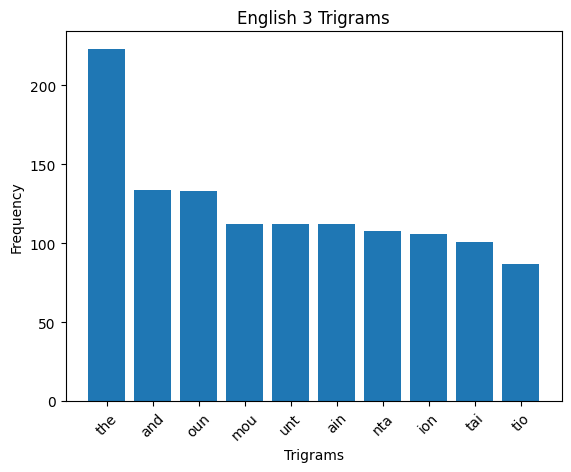

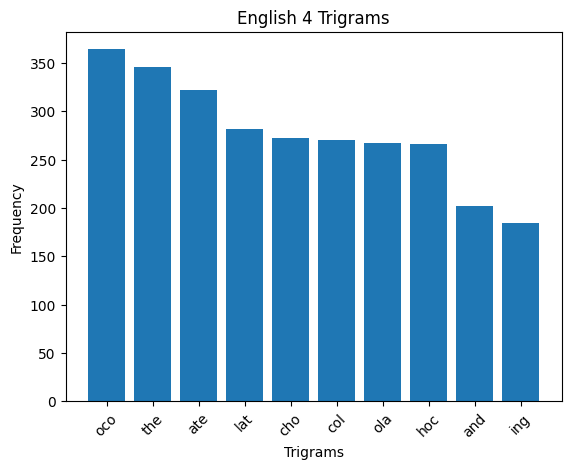

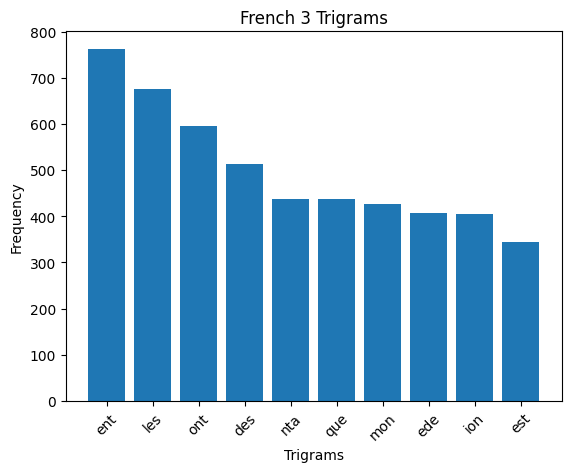

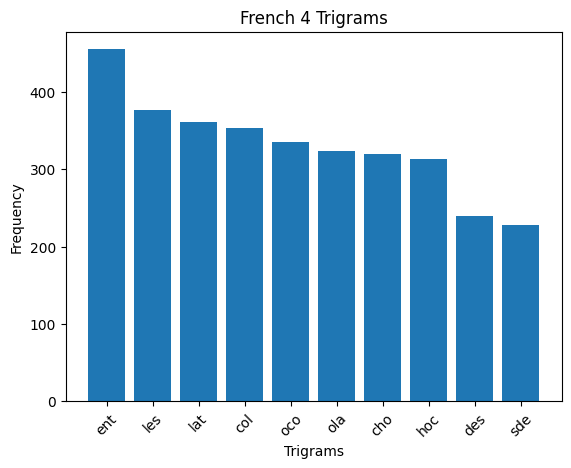

In [106]:
plot_trigrams(trigram_eng3, "English 3 Trigrams")
plot_trigrams(trigram_eng4, "English 4 Trigrams")
plot_trigrams(trigram_fr3, "French 3 Trigrams")
plot_trigrams(trigram_fr4, "French 4 Trigrams")

# Part 2: Written numbers

We will use a subset of the MNIST dataset. Each input character is represented in a 28*28 array. Let us see if we can extract some simple features from these images which can help us distinguish between the digits.

Load the dataset:

In [107]:
from keras.datasets import mnist

#loading the dataset
(train_X, train_y), (test_X, test_y) = mnist.load_data()

Extract a subset of the data for our experiment:

In [108]:
no1 = train_X[train_y==1,:,:]
no0 = train_X[train_y==0,:,:]

Let us visualize a few images here:

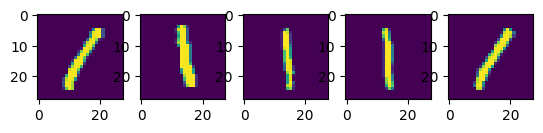

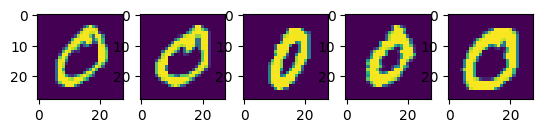

In [109]:
for ii in range(5):
  plt.subplot(1, 5, ii+1)
  plt.imshow(no1[ii,:,:])
plt.show()
for ii in range(5):
  plt.subplot(1, 5, ii+1)
  plt.imshow(no0[ii,:,:])
plt.show()

Now, let us start with a simple feature: the sum of all pixels and see how good this feature is.

In [110]:
sum1 = np.sum(no1>0, (1,2)) # threshold before adding up
sum0 = np.sum(no0>0, (1,2))

Let us visualize how good this feature is: (X-axis is mean, y-axis is the digit)

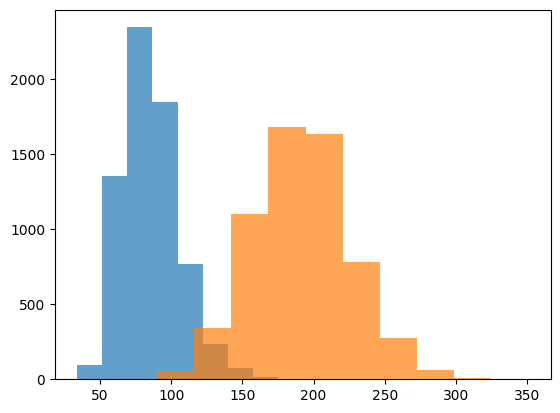

In [111]:
plt.hist(sum1, alpha=0.7);
plt.hist(sum0, alpha=0.7);

We can already see that this feature separates the two classes quite well.

Let us look at another, more complicated feature. We will count the number black pixels that are surrounded on four sides by non-black pixels, or "hole pixels".

In [112]:
def cumArray(img):
  img2 = img.copy()
  for ii in range(1, img2.shape[1]):
    img2[ii,:] = img2[ii,:] + img2[ii-1,:]  # for every row, add up all the rows above it.
  img2 = img2>0
  return img2

def getHolePixels(img):
  im1 = cumArray(img)
  im2 = np.rot90(cumArray(np.rot90(img)), 3) # rotate and cumulate it again for differnt direction
  im3 = np.rot90(cumArray(np.rot90(img, 2)), 2)
  im4 = np.rot90(cumArray(np.rot90(img, 3)), 1)
  hull =  im1 & im2 & im3 & im4 # this will create a binary image with all the holes filled in.
  hole = hull & ~ (img>0) # remove the original digit to leave behind the holes
  return hole

Visualize a few:

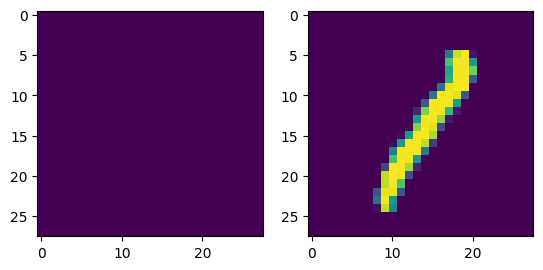

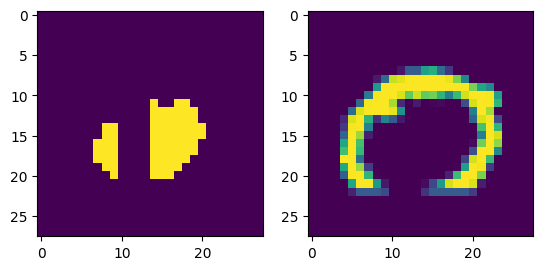

In [113]:
imgs = [no1[456,:,:],  no0[456,:,:]]
for img in imgs:
  plt.subplot(1,2,1)
  plt.imshow(getHolePixels(img))
  plt.subplot(1,2,2)
  plt.imshow(img)
  plt.show()

Now let us plot the number of hole pixels and see how this feature behaves

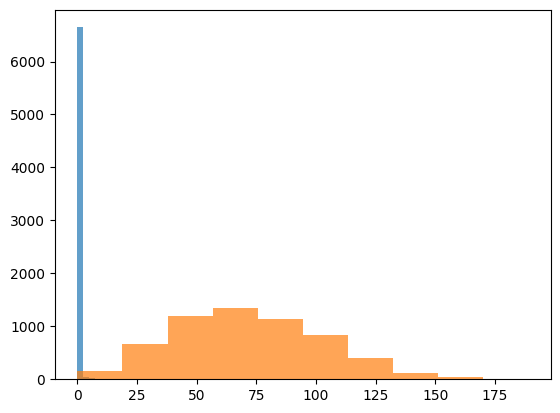

In [114]:
hole1 = np.array([getHolePixels(i).sum() for i in no1])
hole0 = np.array([getHolePixels(i).sum() for i in no0])

plt.hist(hole1, alpha=0.7);
plt.hist(hole0, alpha=0.7);

This feature works even better to distinguish between one and zero.


Now let us try the number of pixels in the 'hull' or the number with the holes filled in:

In [115]:
def getHullPixels(img):
  im1 = cumArray(img)
  im2 = np.rot90(cumArray(np.rot90(img)), 3) # rotate and cumulate it again for differnt direction
  im3 = np.rot90(cumArray(np.rot90(img, 2)), 2)
  im4 = np.rot90(cumArray(np.rot90(img, 3)), 1)
  hull =  im1 & im2 & im3 & im4 # this will create a binary image with all the holes filled in.
  return hull

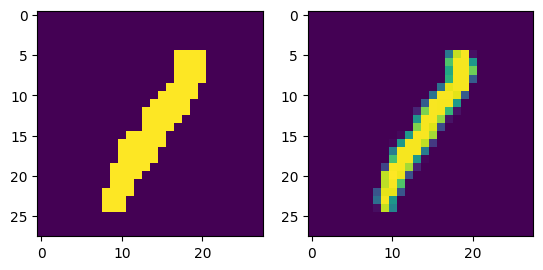

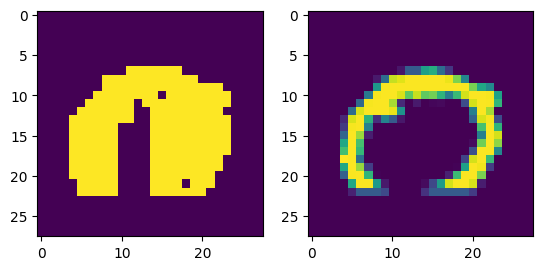

In [116]:
imgs = [no1[456,:,:],  no0[456,:,:]]
for img in imgs:
  plt.subplot(1,2,1)
  plt.imshow(getHullPixels(img))
  plt.subplot(1,2,2)
  plt.imshow(img)
  plt.show()

Plotting the number of hull pixels versus the digit:

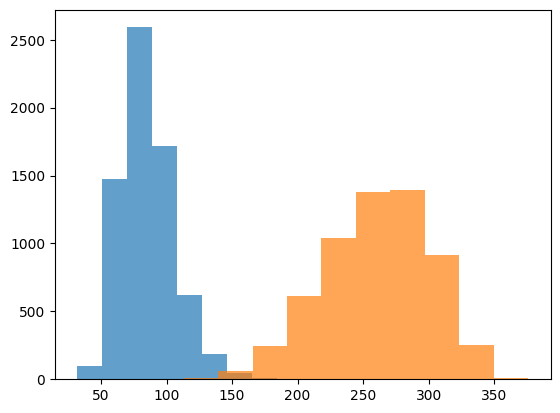

In [117]:
hull1 = np.array([getHullPixels(i).sum() for i in no1])
hull0 = np.array([getHullPixels(i).sum() for i in no0])

plt.hist(hull1, alpha=0.7);
plt.hist(hull0, alpha=0.7);

Let us try one more feature, where we look at the number of boundary pixels in each image.

In [118]:
def minus(a, b):
  return a & ~ b

def getBoundaryPixels(img):
  img = img.copy()>0  # binarize the image
  rshift = np.roll(img, 1, 1)
  lshift = np.roll(img, -1 ,1)
  ushift = np.roll(img, -1, 0)
  dshift = np.roll(img, 1, 0)
  boundary = minus(img, rshift) | minus(img, lshift) | minus(img, ushift) | minus(img, dshift)
  return boundary

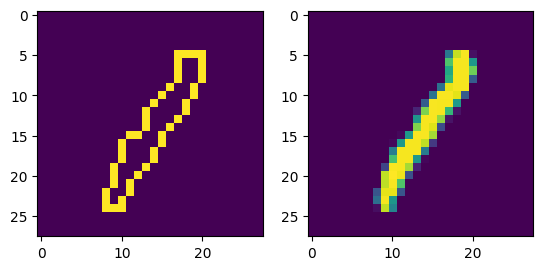

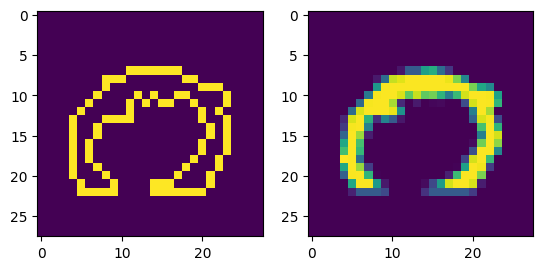

In [119]:
imgs = [no1[456,:,:],  no0[456,:,:]]
for img in imgs:
  plt.subplot(1,2,1)
  plt.imshow(getBoundaryPixels(img))
  plt.subplot(1,2,2)
  plt.imshow(img)
  plt.show()

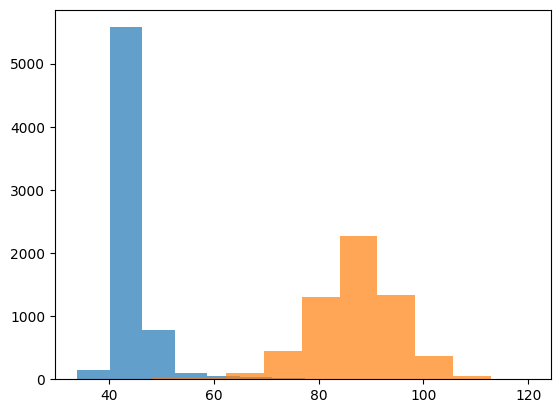

In [120]:
bound1 = np.array([getBoundaryPixels(i).sum() for i in no1])
bound0= np.array([getBoundaryPixels(i).sum() for i in no0])

plt.hist(bound1, alpha=0.7);
plt.hist(bound0, alpha=0.7);

What will happen if we plot two features together?

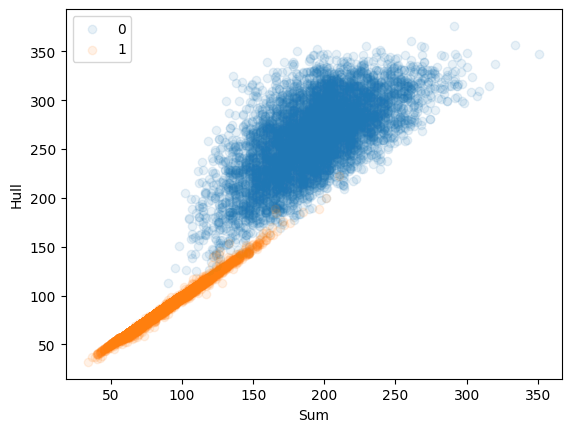

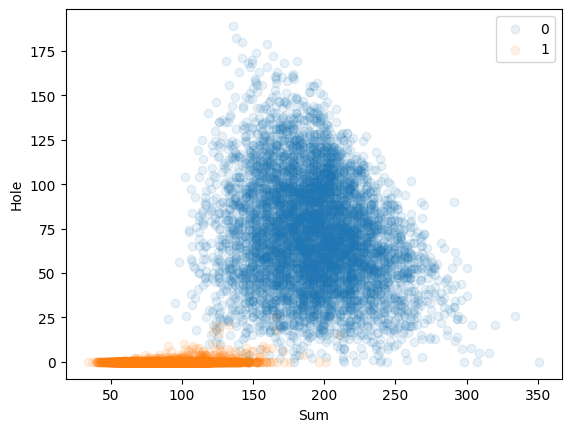

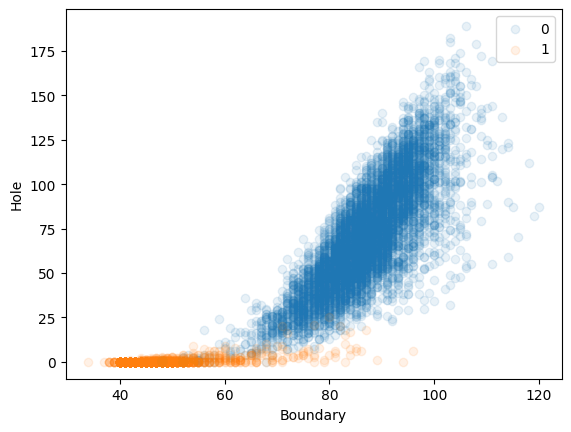

In [121]:
# Sum and hull
plt.scatter(sum0, hull0, alpha=0.1)
plt.scatter(sum1, hull1, alpha=0.1)
plt.xlabel('Sum')
plt.ylabel('Hull')
plt.legend(['0','1'])
plt.show()

# Sum and hole
plt.scatter(sum0, hole0, alpha=0.1)
plt.scatter(sum1, hole1, alpha=0.1)
plt.xlabel('Sum');
plt.ylabel('Hole');
plt.legend(['0','1'])
plt.show()

# Hole and boundary
plt.scatter(bound0, hole0, alpha=0.1)
plt.scatter(bound1, hole1, alpha=0.1)
plt.xlabel('Boundary');
plt.ylabel('Hole');
plt.legend(['0','1'])
plt.show()

Now let us try plotting 3 features together.

In [122]:
cl1 = ['class 1']*len(sum1)
cl0 = ['class 0']*len(sum0)
df = pd.DataFrame(list(zip(np.concatenate((hole0, hole0)), np.concatenate((sum1,sum0)),
                           np.concatenate((bound1,bound0)), np.concatenate((cl1, cl0)))),
               columns =['Hole', 'Sum', 'Boundary', 'Class'])
df.head()
fig = px.scatter_3d(df, x='Hole', y='Sum', z='Boundary', color='Class', opacity=0.1)
fig.show()

###1. Which is the best combination of features?

For the below graphs, we plot features pairwise.

As we can see from the below scatter plots, the plots including the feature hole seperate the digits most accurately.
Hence, the best combination of features can be:
1. Sum and Hole
2. Hull and Hole
3. Boundary and Hole

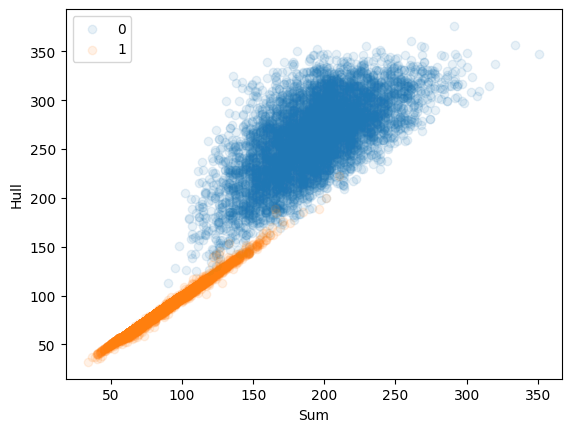

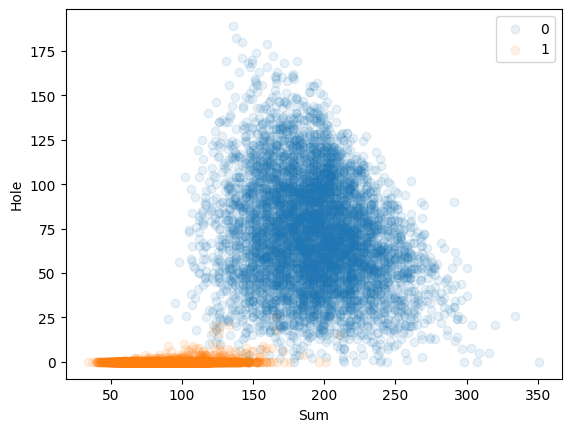

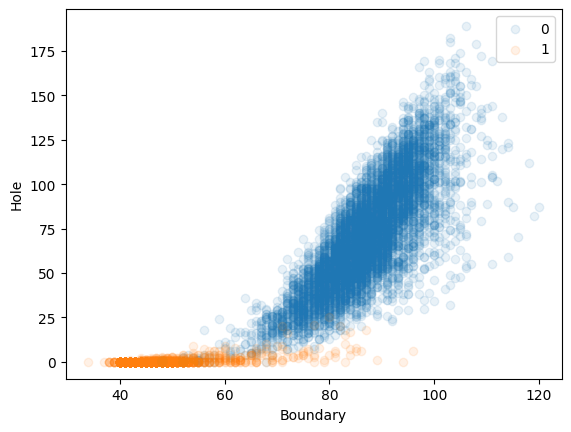

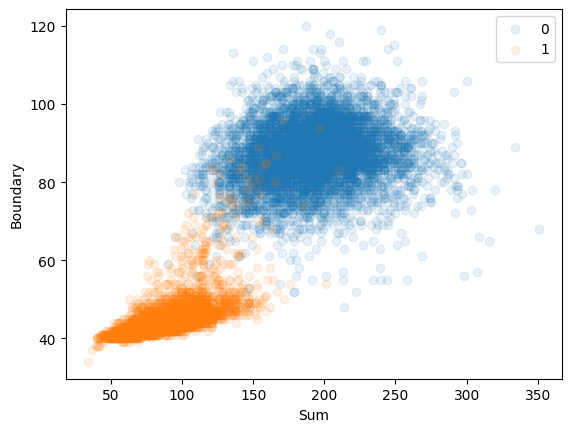

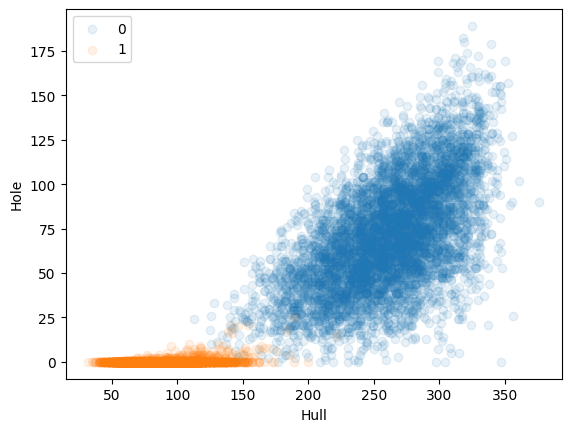

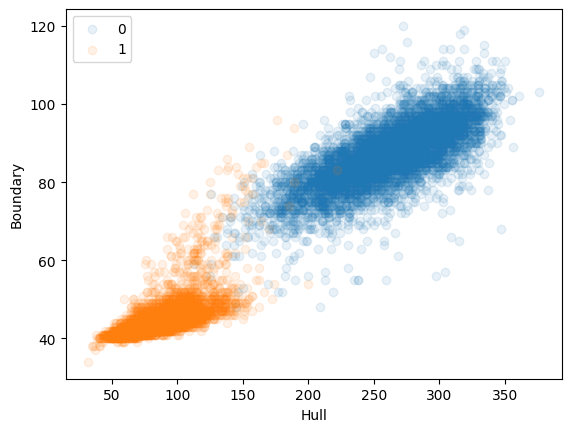

In [123]:
#Sum and Hull
plt.scatter(sum0, hull0, alpha=0.1)
plt.scatter(sum1, hull1, alpha=0.1)
plt.xlabel('Sum')
plt.ylabel('Hull')
plt.legend(['0','1'])
plt.show()

# Sum and hole
plt.scatter(sum0, hole0, alpha=0.1)
plt.scatter(sum1, hole1, alpha=0.1)
plt.xlabel('Sum');
plt.ylabel('Hole');
plt.legend(['0','1'])
plt.show()

# Hole and boundary
plt.scatter(bound0, hole0, alpha=0.1)
plt.scatter(bound1, hole1, alpha=0.1)
plt.xlabel('Boundary');
plt.ylabel('Hole');
plt.legend(['0','1'])
plt.show()

# Sum and boundary
plt.scatter(sum0, bound0, alpha=0.1)
plt.scatter(sum1, bound1, alpha=0.1)

plt.xlabel('Sum')
plt.ylabel('Boundary')

plt.legend(['0','1'])
plt.show()

# Hull and Hole
plt.scatter(hull0, hole0, alpha=0.1)
plt.scatter(hull1, hole1, alpha=0.1)

plt.xlabel('Hull')
plt.ylabel('Hole')

plt.legend(['0','1'])
plt.show()

# Hull and Boundary
plt.scatter(hull0, bound0, alpha=0.1)
plt.scatter(hull1, bound1, alpha=0.1)

plt.xlabel('Hull')
plt.ylabel('Boundary')

plt.legend(['0','1'])
plt.show()

###2. How would you test or visualize four or more features?

Humans cannot visualise more than three dimensions, hence in order to visualise four or more features, we can use pariwise scatter plots like in the previous question.
We can also use techniques like Principal Component Analysis to reduce the number of dimensions.
Additionally, we can also visualise each feature by using a histogram.

###3. Can you come up with your own features?

The features added here are:


1. Width of the digit i.e. rightmost pixel - leftmost pixel

In [124]:
import numpy as np

def getWidth(img):
    cols = np.where(img > 0)[1]   # columns containing pixels
    return cols.max() - cols.min() if len(cols) > 0 else 0

In [125]:
width1 = np.array([getWidth(i) for i in no1])
width0 = np.array([getWidth(i) for i in no0])

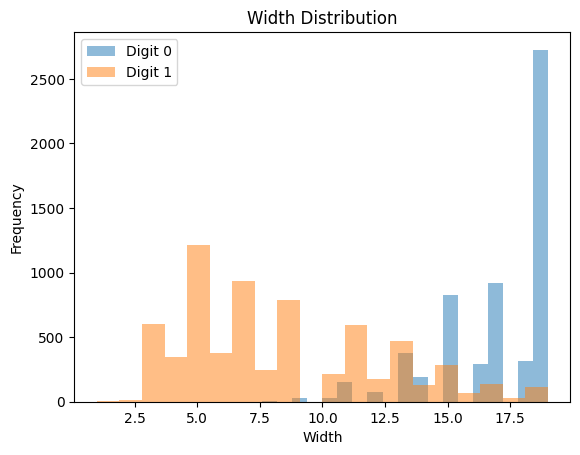

In [126]:
plt.figure()

plt.hist(width0, bins=20, alpha=0.5, label="Digit 0")
plt.hist(width1, bins=20, alpha=0.5, label="Digit 1")

plt.xlabel("Width")
plt.ylabel("Frequency")
plt.title("Width Distribution")

plt.legend()
plt.show()

2. Symmetry

In [127]:
def getSymmetry(img):
    left = img[:, :14]
    right = img[:, 14:]

    right_flipped = np.fliplr(right)

    diff = np.abs(left - right_flipped)

    return diff.sum()

In [128]:
sym1 = np.array([getSymmetry(i) for i in no1])
sym0 = np.array([getSymmetry(i) for i in no0])

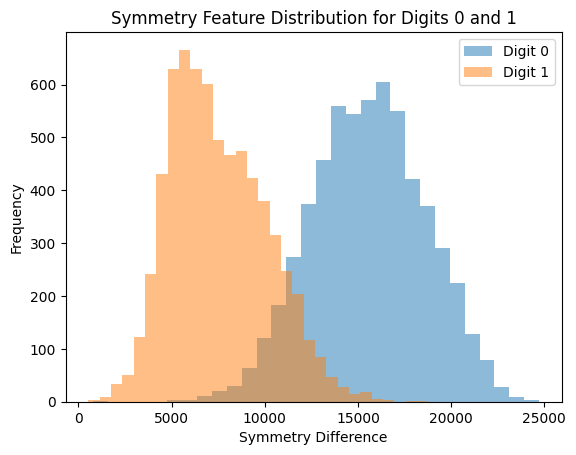

In [129]:
plt.figure()

plt.hist(sym0, bins=30, alpha=0.5, label="Digit 0")
plt.hist(sym1, bins=30, alpha=0.5, label="Digit 1")

plt.xlabel("Symmetry Difference")
plt.ylabel("Frequency")
plt.title("Symmetry Feature Distribution for Digits 0 and 1")

plt.legend()
plt.show()

###4. Will these features work for different classes other than 0 and 1?

From the below graphs, we can see that these features work very well for:
1. Sum and Hull
2. Hole and Sum
3. Sum and Boundary

The seperation is very clear, and the two classes and cleanly seperated.

Whereas for 1 and 0, Sum and Hull and Boundary and Hull did not work as well as they do here. Even Hole and Sum was not as accurate as it is here.


However, they do not work well for:
1. Hole and Boundary
2. Hole and Hull
3. Hull and Boundary

The seperation is not clear here, with a lot of points getting overlapped.

Whereas, Hole and Hull worked well for 0 and 1, and even Hole and Boundary, and Hull and Boundary gave moderate seperation.

Hence, features that work for two specific classes may not always work for other classes.

In [130]:
no8 = train_X[train_y == 8,:,:]

A few visualised images are:

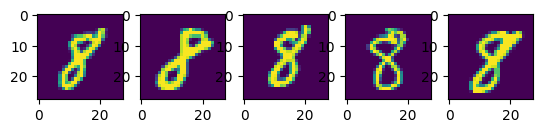

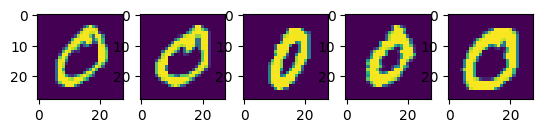

In [131]:
for ii in range(5):
  plt.subplot(1, 5, ii+1)
  plt.imshow(no8[ii,:,:])
plt.show()
for ii in range(5):
  plt.subplot(1, 5, ii+1)
  plt.imshow(no0[ii,:,:])
plt.show()

Here, we are calculating the sum of all pixels, hole pixels, boundary pixels and the hull pixels of the number 8.

In [132]:
sum8 = np.array([i.sum() for i in no8])
hole8 = np.array([getHolePixels(i).sum() for i in no8])
bound8 = np.array([getBoundaryPixels(i).sum() for i in no8])
hull8 = np.array([getHullPixels(i).sum() for i in no8])

Plotting all these features pairwise in a scatter plot, we get:

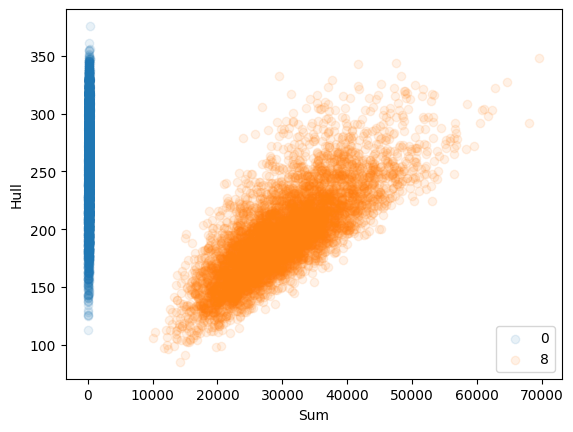

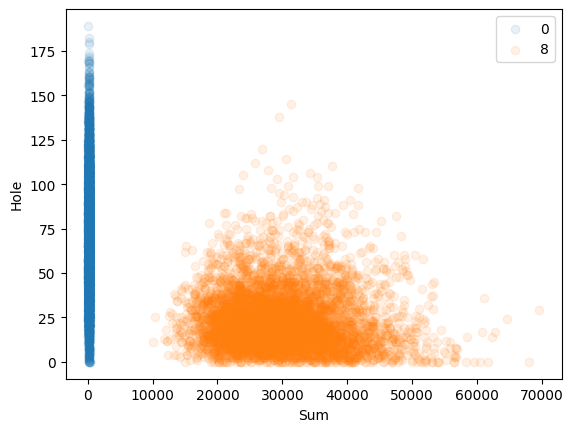

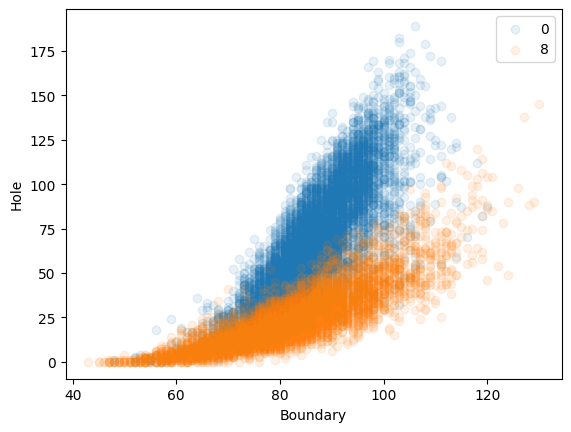

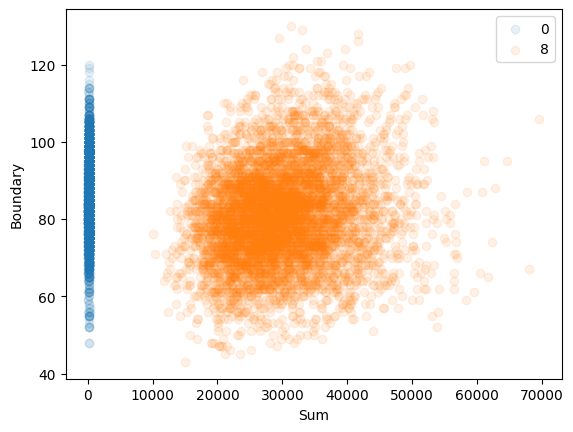

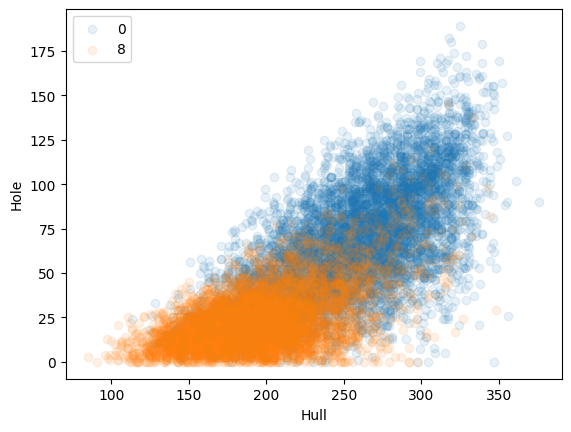

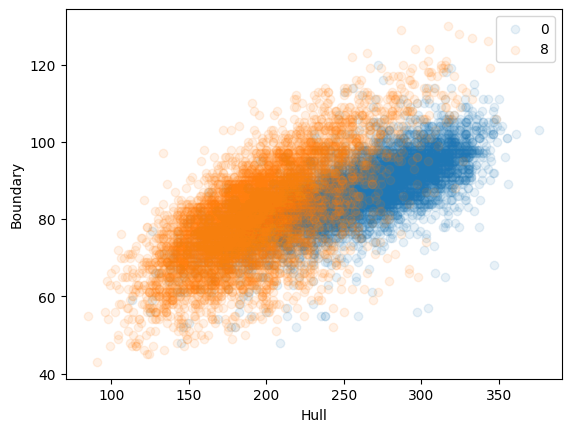

In [133]:
plt.scatter(sum0, hull0, alpha=0.1)
plt.scatter(sum8, hull8, alpha=0.1)
plt.xlabel('Sum')
plt.ylabel('Hull')
plt.legend(['0','8'])
plt.show()

# Sum and hole
plt.scatter(sum0, hole0, alpha=0.1)
plt.scatter(sum8, hole8, alpha=0.1)
plt.xlabel('Sum');
plt.ylabel('Hole');
plt.legend(['0','8'])
plt.show()

# Hole and boundary
plt.scatter(bound0, hole0, alpha=0.1)
plt.scatter(bound8, hole8, alpha=0.1)
plt.xlabel('Boundary');
plt.ylabel('Hole');
plt.legend(['0','8'])
plt.show()

# Sum and boundary
plt.scatter(sum0, bound0, alpha=0.1)
plt.scatter(sum8, bound8, alpha=0.1)

plt.xlabel('Sum')
plt.ylabel('Boundary')

plt.legend(['0','8'])
plt.show()

# Hull and Hole
plt.scatter(hull0, hole0, alpha=0.1)
plt.scatter(hull8, hole8, alpha=0.1)

plt.xlabel('Hull')
plt.ylabel('Hole')

plt.legend(['0','8'])
plt.show()

# Hull and Boundary
plt.scatter(hull0, bound0, alpha=0.1)
plt.scatter(hull8, bound8, alpha=0.1)

plt.xlabel('Hull')
plt.ylabel('Boundary')

plt.legend(['0','8'])
plt.show()

### 5. What will happen if we take more that two classes at a time?

Here, we have taken 3 classes, namely 0, 1 and 8.

As we can see from the graphs, when classes get increased, points overlap more, and it becomes more difficult to classify, compelling us to use more features, or different distinct features in order to properly classify them.

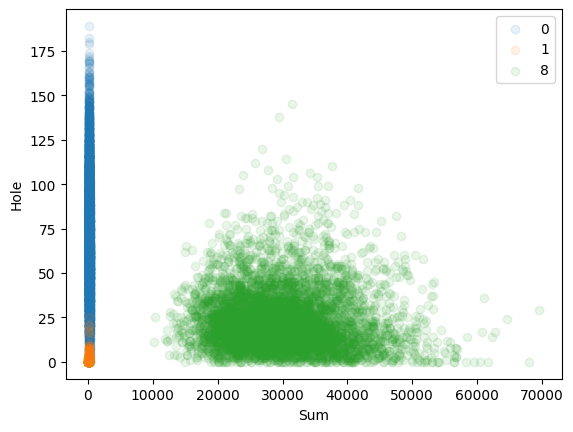

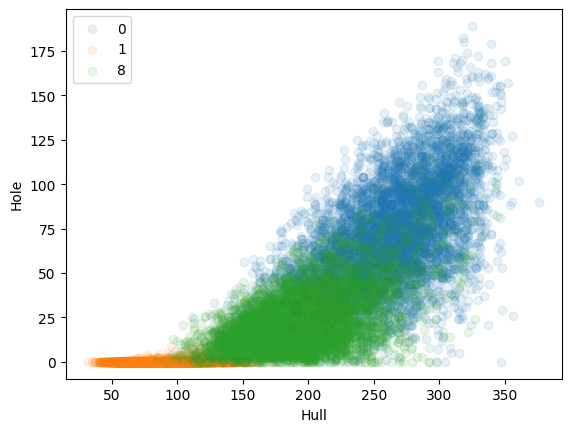

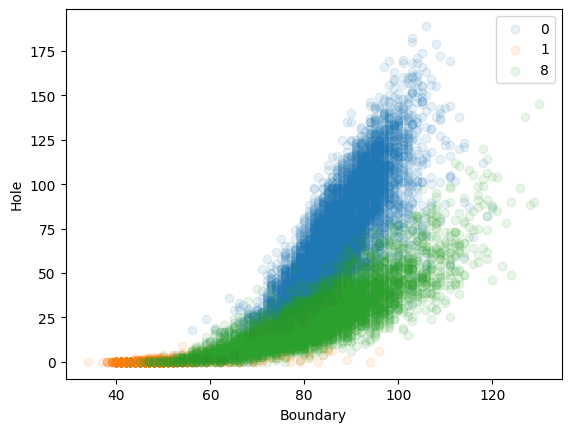

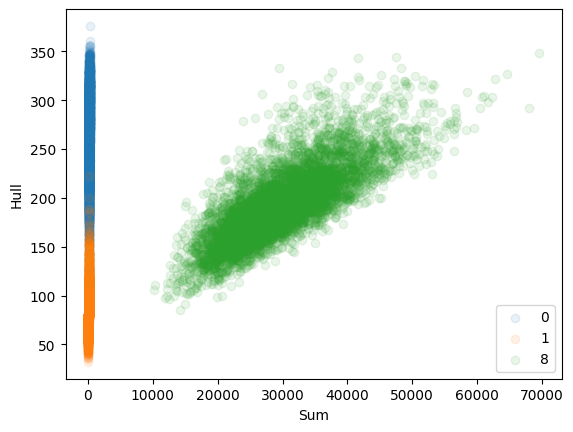

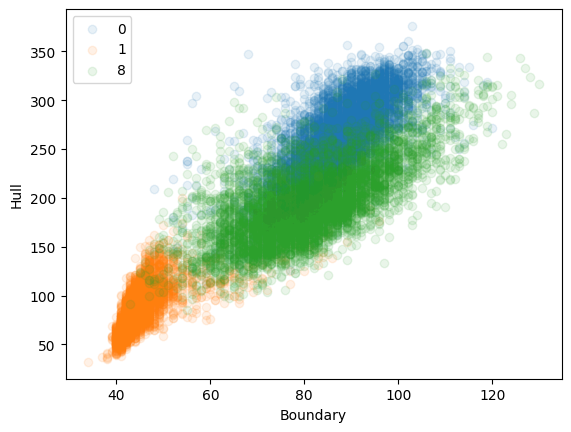

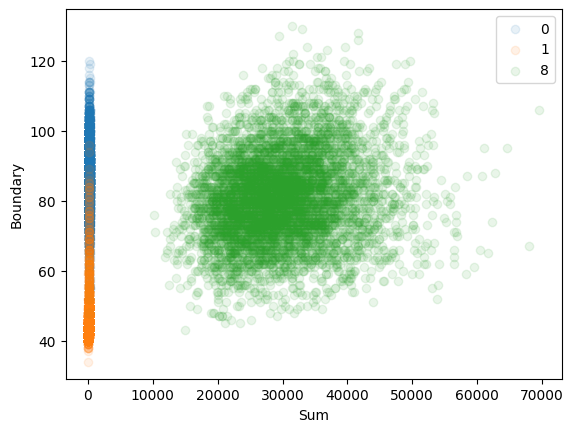

In [134]:
#Sum and Hole
plt.scatter(sum0, hole0, alpha=0.1)
plt.scatter(sum1, hole1, alpha=0.1)
plt.scatter(sum8, hole8, alpha=0.1)

plt.xlabel("Sum")
plt.ylabel("Hole")

plt.legend(["0","1","8"])
plt.show()

#Hull and Hole
plt.scatter(hull0, hole0, alpha=0.1)
plt.scatter(hull1, hole1, alpha=0.1)
plt.scatter(hull8, hole8, alpha=0.1)

plt.xlabel("Hull")
plt.ylabel("Hole")

plt.legend(["0","1","8"])
plt.show()

#Boundary and Hole
plt.scatter(bound0, hole0, alpha=0.1)
plt.scatter(bound1, hole1, alpha=0.1)
plt.scatter(bound8, hole8, alpha=0.1)

plt.xlabel("Boundary")
plt.ylabel("Hole")

plt.legend(["0","1","8"])
plt.show()

#Sum and Hull
plt.scatter(sum0, hull0, alpha=0.1)
plt.scatter(sum1, hull1, alpha=0.1)
plt.scatter(sum8, hull8, alpha=0.1)

plt.xlabel("Sum")
plt.ylabel("Hull")

plt.legend(["0","1","8"])
plt.show()

#Boundary and Hull
plt.scatter(bound0, hull0, alpha=0.1)
plt.scatter(bound1, hull1, alpha=0.1)
plt.scatter(bound8, hull8, alpha=0.1)

plt.xlabel("Boundary")
plt.ylabel("Hull")

plt.legend(["0","1","8"])
plt.show()

#Sum and Boundary
plt.scatter(sum0, bound0, alpha=0.1)
plt.scatter(sum1, bound1, alpha=0.1)
plt.scatter(sum8, bound8, alpha=0.1)

plt.xlabel("Sum")
plt.ylabel("Boundary")

plt.legend(["0","1","8"])
plt.show()